# Customer Churn Prediction

This project aims to predict customer churn using supervised machine learning techniques.  
The primary objective is to identify customers who are at high risk of discontinuing the service, enabling data-driven and proactive retention strategies.

The notebook is structured as an end-to-end machine learning workflow and includes:
- Exploratory data analysis (EDA) to understand customer behavior and key patterns
- Data preprocessing and feature engineering
- Development and evaluation of multiple classification models
- Model comparison and selection of a final model
- Interpretation of the selected model to extract actionable insights

Model performance is evaluated with a focus on recall for the churn class and ROC AUC, aligning the evaluation strategy with the business goal of minimizing missed churn cases.

*Importing Libraries*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

## Dataset Overview

The dataset contains customer-level information related to demographics, services, and account details.  
The target variable is `Churn`, indicating whether a customer has discontinued the service.

*Loading in the Data*

In [2]:
df = pd.read_csv("Telco Customer Churn.csv")

*Viewing the Data*

In [3]:
df.shape

(7043, 21)

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution of the target variable, identify patterns in numerical features, and explore relationships between categorical features and churn behavior.

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include= "object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


*Assessing Missing Values*

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

*Data Exploration*

In [10]:
# -----------------------------
# 1. Set the style and font of the entire project
# -----------------------------
sns.set_theme(
    style= "ticks",
    context= "notebook",
    font= "Times New Roman",
    font_scale= 1.1
)

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# -----------------------------
# 2. Smart annotation function
# -----------------------------
def annotate_bars_smart(ax_or_g, max_categories_inline= 5):
    """
    Smart annotation for countplot or catplot (FacetGrid).
    Automatically places numbers inside bars if possible, adjusts rotation and color.
    """    
    # FacetGrid detection
    if isinstance(ax_or_g, sns.axisgrid.FacetGrid):
        axes = ax_or_g.axes.flat
    else:
        axes = [ax_or_g]

    for ax in axes:
        containers = getattr(ax, "containers", [])
        if not containers:
            containers = [c for c in getattr(ax, "containers", [])]
        
        num_bars = sum(len(c) for c in containers) // max(1, len(containers))
        
        
        if num_bars <= max_categories_inline:
            rotation = 0
            va = "center"
            offset = 0
        else:
            rotation = 90
            va = "bottom"
            offset = 3

        for container in containers:
            for patch in container:
                height = patch.get_height()
                if height > 0:
                    x = patch.get_x() + patch.get_width() / 2
                    y = height / 2 if num_bars <= max_categories_inline else height + offset
                    facecolor = patch.get_facecolor()
                    color = "white" if sum(facecolor[:3])/3 < 0.6 else "black"

                    ax.text(
                        x, y, f"{int(height)}",
                        ha= "center",
                        va= va,
                        rotation= rotation,
                        fontsize= 10,
                        fontweight= "bold",
                        color=color
                    )
        ax.grid(False)

# -----------------------------
# 3. Catplot plot template
# -----------------------------
def plot_catplot(data, x, hue= None, kind= "count", palette= None, title= "", xlabel= None, ylabel= "Count", height= 5, aspect= 1.4):
    g = sns.catplot(
        data= data,
        x= x,
        hue= hue,
        kind= kind,
        palette= palette,
        height= height,
        aspect= aspect
    )
    g.set(title= title, xlabel= xlabel or x, ylabel= ylabel)
    if hue: g._legend.set_title(hue)
    annotate_bars_smart(g)
    plt.tight_layout()
    plt.show()
    return g

# -----------------------------
# 4. Countplot plot template
# -----------------------------
def plot_countplot(data, x, hue= None, palette= None, title= "", xlabel= None, ylabel= "Count"):
    ax = sns.countplot(data=data, x=x, hue=hue, palette=palette)
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)
    if hue: ax.legend(title=hue)
    annotate_bars_smart(ax)
    plt.tight_layout()
    plt.show()
    return ax

# -----------------------------
# 5. Boxplot drawing format
# -----------------------------
def plot_boxplot(data, x= None, y= None, hue= None, palette= None, title= "", xlabel= None, ylabel= None):
    ax = sns.boxplot(data= data, x= x, y= y, hue= hue, palette= palette)
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    if hue: ax.legend(title=hue)
    plt.tight_layout()
    plt.show()
    return ax

# -----------------------------
# 6. Histplot plot format
# -----------------------------
def plot_histplot(data, x, hue= None, palette= None, bins= 30, multiple= "stack", title= "", xlabel= None, ylabel= "Count"):
    ax = sns.histplot(data= data, x= x, hue= hue, palette= palette, bins= bins, multiple= multiple)
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    plt.tight_layout()
    plt.show()
    return ax

Text(0.5, 1.0, 'Customer Churn Prediction Missing Value')

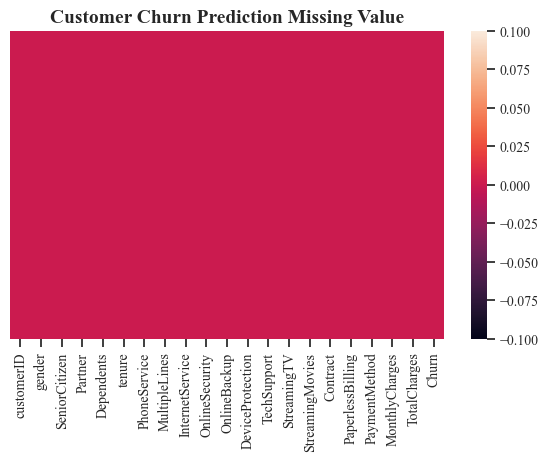

In [11]:
ax = sns.heatmap(df.isnull(), yticklabels= False, cbar= True)

ax.set_title("Customer Churn Prediction Missing Value")

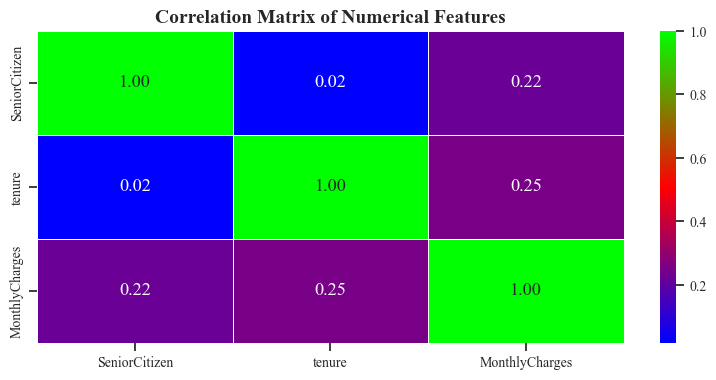

In [12]:
plt.figure(figsize= (8, 4))
sns.heatmap(
    df.select_dtypes(include= "number").corr(),
    annot= True,
    fmt= ".2f",
    cmap= "brg",
    linewidths= 0.5
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

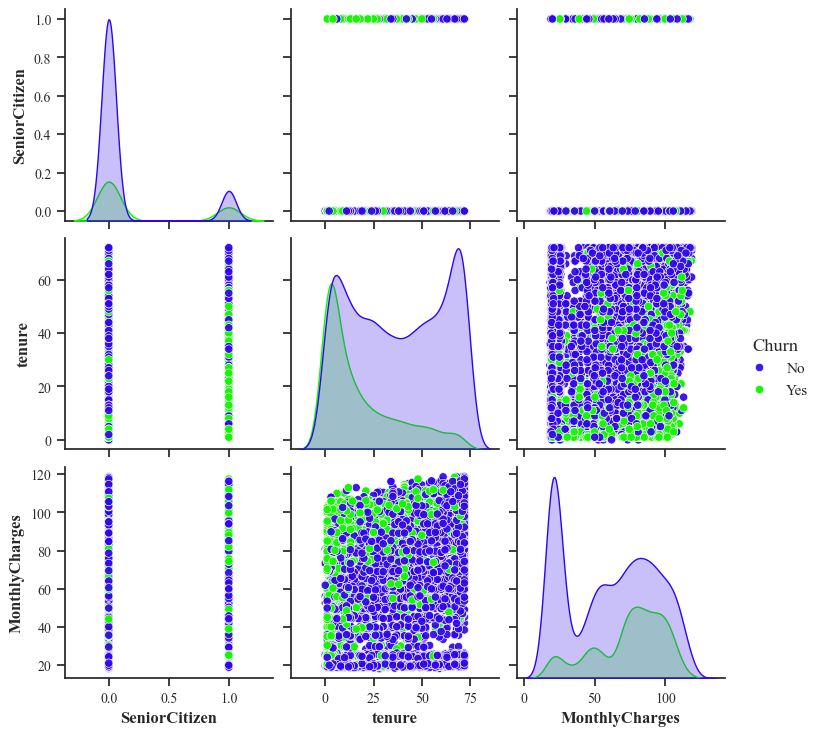

In [13]:
sns.pairplot(df, hue= "Churn", palette=["#2F05EBEA", "#15F701"])

*Assessing unique values*

In [14]:
columns_of_customer_churn = df.columns

In [15]:
for i in columns_of_customer_churn:
    print(df[i].unique())

['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
['No' 'Yes']


C:\Users\Hediye\AppData\Local\Temp\ipykernel_9316\1778859234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the groupin

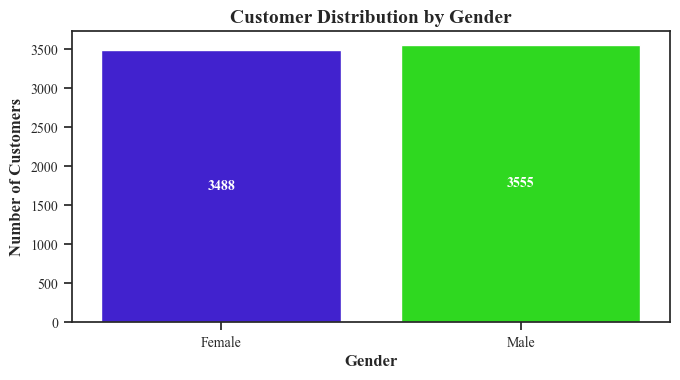

In [16]:
ax = sns.countplot(
    data= df,
    x= "gender",
    palette=["#2F05EBEA", "#15F701"]
)

ax.set_title("Customer Distribution by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Number of Customers")

annotate_bars_smart(ax)
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

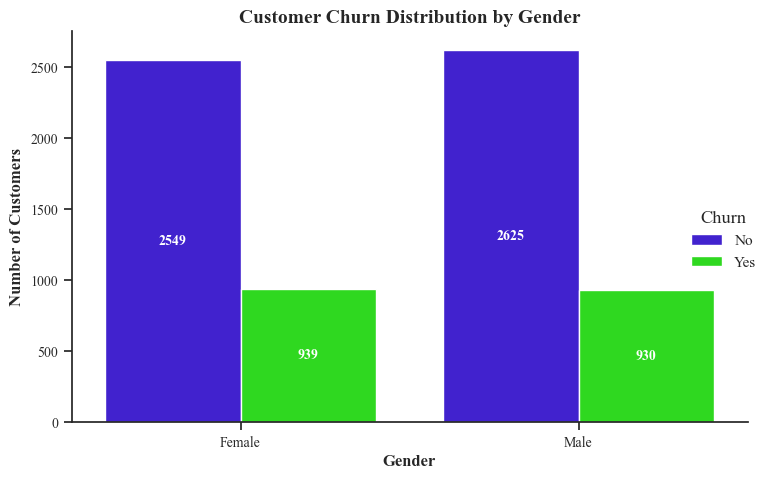

In [17]:
g = sns.catplot(
    data= df,
    x= "gender",
    hue= "Churn",
    kind= "count",
    palette=["#2F05EBEA", "#15F701"],
    height=5,        
    aspect= 1.4 
)

g.set(
    title= "Customer Churn Distribution by Gender",
    xlabel= "Gender",
    ylabel= "Number of Customers"
)

g._legend.set_title("Churn")

annotate_bars_smart(g)
plt.tight_layout()
plt.show()

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9316\2341855488.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the groupin

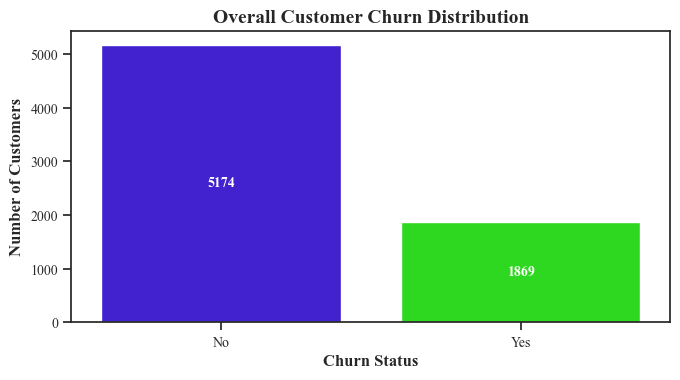

In [18]:
ax = sns.countplot(
    data= df,
    x="Churn",
    palette=["#2F05EBEA", "#15F701"]
)

ax.set_title("Overall Customer Churn Distribution")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Number of Customers")

annotate_bars_smart(ax)
plt.tight_layout()
plt.show()

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9316\2976721933.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the groupin

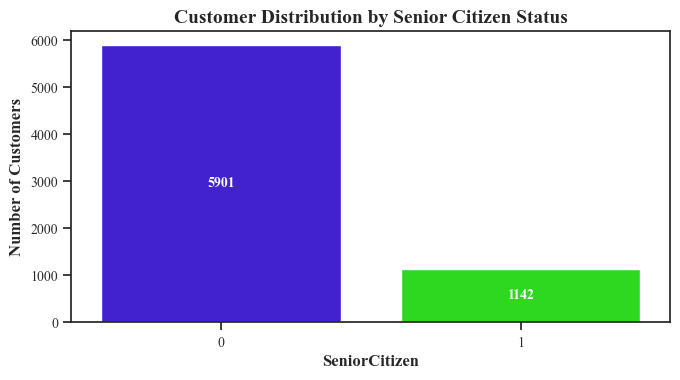

In [19]:
ax = sns.countplot(
    data= df,
    x= "SeniorCitizen",
    palette=["#2F05EBEA", "#15F701"]
)

ax.set_title("Customer Distribution by Senior Citizen Status")
ax.set_xlabel("SeniorCitizen")
ax.set_ylabel("Number of Customers")

annotate_bars_smart(ax)
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

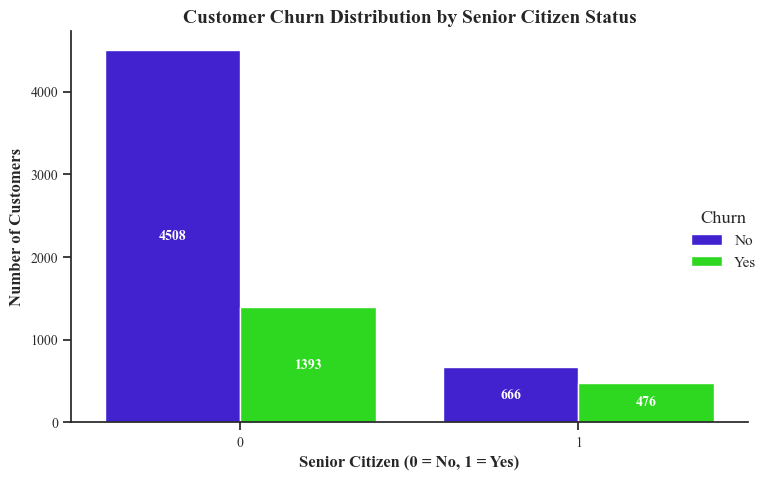

In [20]:
g = sns.catplot(
    data= df,
    x= "SeniorCitizen",
    hue= "Churn",
    kind= "count",
    palette=["#2F05EBEA", "#15F701"],
    height= 5,        
    aspect= 1.4 
)
g.set(
    title="Customer Churn Distribution by Senior Citizen Status",
    xlabel="Senior Citizen (0 = No, 1 = Yes)",
    ylabel="Number of Customers"
)

g._legend.set_title("Churn")

annotate_bars_smart(g)
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

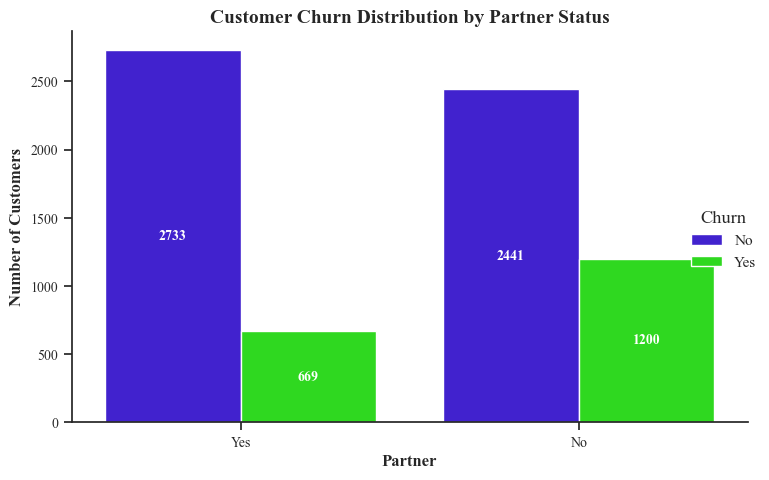

In [21]:
g = sns.catplot(
    data= df,
    x= "Partner", 
    hue= "Churn",
    kind= "count",
    palette=["#2F05EBEA", "#15F701"],
    height= 5,        
    aspect= 1.4 )

g.set(
    title="Customer Churn Distribution by Partner Status",
    xlabel="Partner",
    ylabel="Number of Customers"
)

g._legend.set_title("Churn")

annotate_bars_smart(g)
plt.tight_layout()
plt.show()

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9316\1692923585.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the groupin

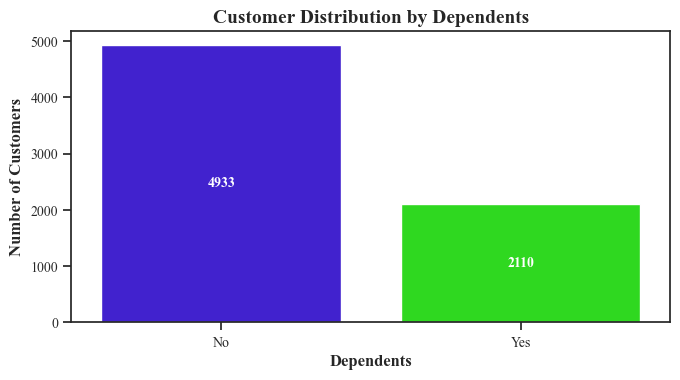

In [22]:
ax = sns.countplot(
    data= df,
    x= "Dependents", 
    palette=["#2F05EBEA", "#15F701"]
)

ax.set_title("Customer Distribution by Dependents")
ax.set_xlabel("Dependents")
ax.set_ylabel("Number of Customers")

annotate_bars_smart(ax)
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

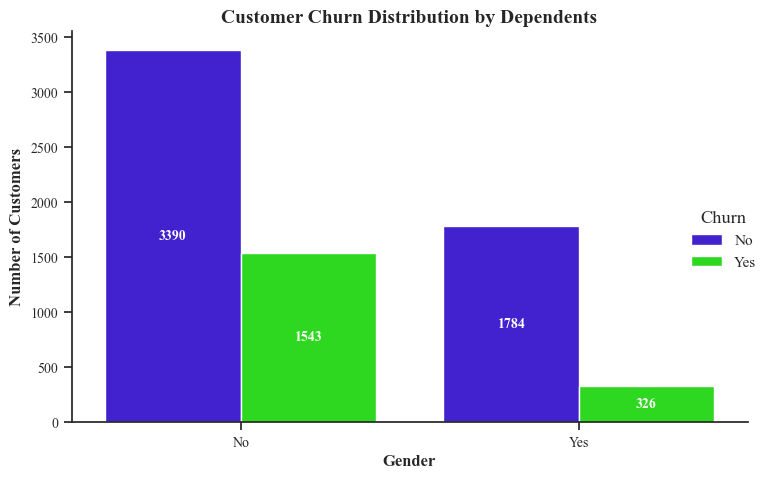

In [23]:
g = sns.catplot(
    data= df,
    x= "Dependents", 
    hue= "Churn", 
    kind= "count",
    palette=["#2F05EBEA", "#15F701"],
    height= 5,        
    aspect= 1.4 
)

g.set(
    title= "Customer Churn Distribution by Dependents",
    xlabel= "Gender",
    ylabel= "Number of Customers"
)

g._legend.set_title("Churn")

annotate_bars_smart(g)
plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to

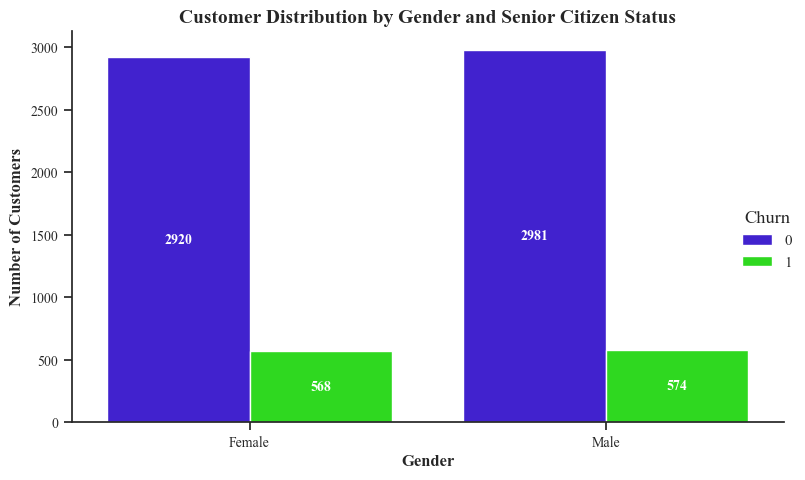

In [24]:
g = sns.catplot(
    data= df,
    x= "gender", 
    hue= "SeniorCitizen",
    kind= "count", 
    palette=["#2F05EBEA", "#15F701"],
    height= 5,        
    aspect= 1.4 
)

g.set(
    title= "Customer Distribution by Gender and Senior Citizen Status",
    xlabel= "Gender",
    ylabel= "Number of Customers"
)

g._legend.set_title("Churn")

annotate_bars_smart(g)
plt.tight_layout()
plt.show()

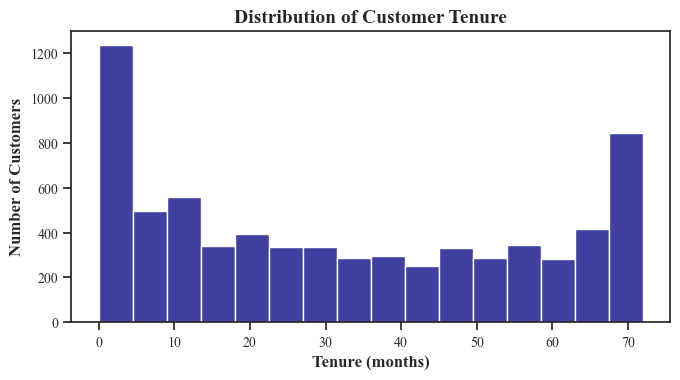

In [25]:
ax = sns.histplot(
    data= df, 
    x= "tenure", 
    color= "navy")


ax.set_title("Distribution of Customer Tenure")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_dat

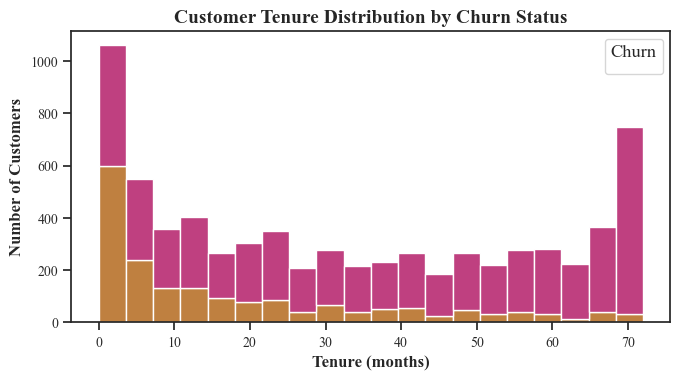

In [26]:
ax= sns.histplot(
    data= df, 
    x= "tenure", 
    hue= "Churn",
    multiple= "stack",
    bins= 20, 
    palette= "brg",)

ax.set_title("Customer Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend(title= "Churn")

plt.tight_layout()
plt.show()

C:\Users\Hediye\AppData\Local\Temp\ipykernel_9316\584955848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\Hediye\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping wi

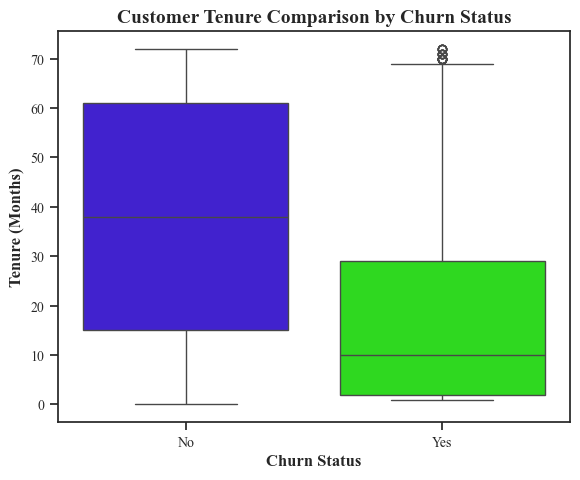

In [27]:
plt.figure(figsize= (6, 5))

sns.boxplot(
    data= df,
    x="Churn",
    y="tenure",
    palette=["#2F05EBEA", "#15F701"]
)

plt.title("Customer Tenure Comparison by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

## Data Preprocessing

This section covers data cleaning, encoding of categorical variables, feature scaling, and splitting the data into training and test sets.  
Class imbalance is handled to ensure the model effectively learns patterns related to churned customers.

In [28]:
df.shape

(7043, 21)

In [29]:
df.drop(columns=["customerID", "TotalCharges"], inplace= True)

In [30]:
X = df.drop(columns= ["Churn"], axis= 1)
y = df["Churn"]

In [31]:
print(f"Shape of x : {X.shape}")
print(f"Shape of y : {y.shape}")
print(f"Value_Count y : {y.value_counts()}")

Shape of x : (7043, 18)
Shape of y : (7043,)
Value_Count y : Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [32]:
y = y.map({"No": 0, "Yes": 1})

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42,
    stratify= y
)

In [34]:
print("Train class distribution:")
print(y_train.value_counts(normalize= True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize= True))

Train class distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test class distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [35]:
numerical_features = ["tenure", "MonthlyCharges"]
binary_features = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
categorical_features = ["gender", "MultipleLines", "InternetService", "OnlineSecurity","OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

In [36]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
binary_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="if_binary"))
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [37]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", numeric_transformer, numerical_features),
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features)
    ]
    )

## Baseline Model

A logistic regression model is used as the baseline due to its simplicity, interpretability, and suitability for binary classification problems.

*Logistic Regression*

In [38]:
lr_model = Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter= 1000))
])

In [39]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred_lr = lr_model.predict(X_test)

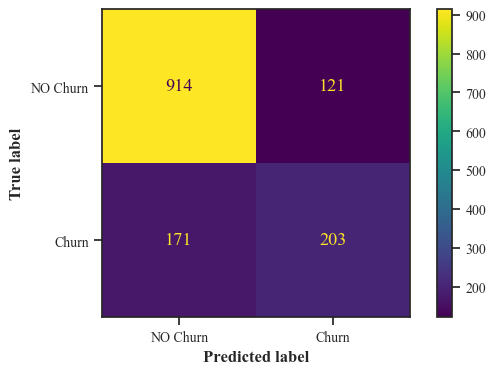

In [41]:
cm = confusion_matrix(y_test, y_pred_lr)
display = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels= ["NO Churn", "Churn"]
)
display.plot()

In [42]:
print(f"Classification Repoet: \n{classification_report(y_test, y_pred_lr)}")

Classification Repoet: 
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



ROC AUC: 0.8377638275336485


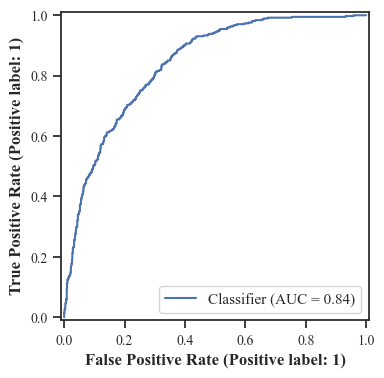

In [43]:
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba_lr)
print("ROC AUC:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_proba_lr)

## Threshold Optimization

Decision threshold analysis is performed to improve recall for the churn class, reflecting the business priority of minimizing false negatives.

In [44]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_lr_thresh = (y_proba_lr >= t).astype(int)

    precision = precision_score(y_test, y_pred_lr_thresh)
    recall = recall_score(y_test, y_pred_lr_thresh)
    f1 = f1_score(y_test, y_pred_lr_thresh)

    results.append((t, precision, recall, f1))

In [45]:
for t, p, r, f in results:
    print(f"Threshold={t:.2f} | Precision={p:.2f} | Recall={r:.2f} | F1={f:.2f}")

Threshold=0.10 | Precision=0.40 | Recall=0.95 | F1=0.56
Threshold=0.15 | Precision=0.44 | Recall=0.91 | F1=0.59
Threshold=0.20 | Precision=0.47 | Recall=0.85 | F1=0.61
Threshold=0.25 | Precision=0.49 | Recall=0.79 | F1=0.61
Threshold=0.30 | Precision=0.52 | Recall=0.74 | F1=0.61
Threshold=0.35 | Precision=0.55 | Recall=0.70 | F1=0.62
Threshold=0.40 | Precision=0.57 | Recall=0.66 | F1=0.61
Threshold=0.45 | Precision=0.61 | Recall=0.61 | F1=0.61
Threshold=0.50 | Precision=0.63 | Recall=0.54 | F1=0.58
Threshold=0.55 | Precision=0.67 | Recall=0.47 | F1=0.55
Threshold=0.60 | Precision=0.71 | Recall=0.40 | F1=0.51
Threshold=0.65 | Precision=0.72 | Recall=0.30 | F1=0.42
Threshold=0.70 | Precision=0.72 | Recall=0.19 | F1=0.30
Threshold=0.75 | Precision=0.81 | Recall=0.11 | F1=0.20
Threshold=0.80 | Precision=0.76 | Recall=0.03 | F1=0.07
Threshold=0.85 | Precision=1.00 | Recall=0.01 | F1=0.01


In [46]:
best_threshold = 0.15
y_pred_lr_final = (y_proba_lr >= best_threshold).astype(int)

In [47]:
print(classification_report(y_test, y_pred_lr_final))

confusion_matrix(y_test, y_pred_lr_final)

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1035
           1       0.44      0.91      0.59       374

    accuracy                           0.67      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.67      0.69      1409



array([[602, 433],
       [ 34, 340]], dtype=int64)

In [48]:
baseline_threshold = 0.5
y_pred_lr_final = (y_proba_lr >= baseline_threshold).astype(int)
print(classification_report(y_test, y_pred_lr_final))

confusion_matrix(y_test, y_pred_lr_final)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



array([[914, 121],
       [171, 203]], dtype=int64)

In [49]:
tuned_threshold = 0.20
y_pred_lr_final = (y_proba_lr >= tuned_threshold).astype(int)
print(classification_report(y_test, y_pred_lr_final))

confusion_matrix(y_test, y_pred_lr_final)

              precision    recall  f1-score   support

           0       0.92      0.65      0.77      1035
           1       0.47      0.85      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.72      1409



array([[677, 358],
       [ 56, 318]], dtype=int64)

In [50]:
lr_model_weighted = Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter= 1000,
        class_weight= "balanced",
        random_state= 42
    ))
])

In [51]:
lr_model_weighted.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
y_pred_lr_w = lr_model_weighted.predict(X_test)
y_proba_lr_w = lr_model_weighted.predict_proba(X_test)[:,1]

In [53]:
print(classification_report(y_test, y_pred_lr_w))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr_w))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

ROC AUC: 0.8373117362887182


In [54]:
final_lr_report = classification_report(y_test, y_pred_lr_w, output_dict=True)
final_lr_auc = roc_auc_score(y_test, y_proba_lr_w)

In [55]:
# ================================
# Final Baseline Model
# Logistic Regression (class_weight="balanced")
# ================================

*RandomForest*

In [56]:
rf_model= Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators= 300,
        max_depth= None,
        min_samples_split= 5,
        min_samples_leaf= 2,
        class_weight= "balanced",
        random_state= 42,
        n_jobs= -1
    ))
])

In [57]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

ROC AUC: 0.8273127696401353


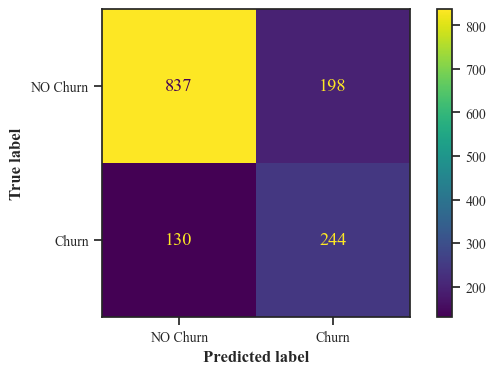

In [59]:
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels= ["NO Churn", "Churn"]
)
display.plot()

In [60]:
# =========================================
# Frozen Comparison Model
# Random Forest Classifier
# =========================================

*Gradient Boosting*

In [61]:
gb_model = Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators= 200,
        learning_rate= 0.5,
        max_depth= 3,
        random_state= 42
    ))
])

In [62]:
gb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_gb))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.57      0.49      0.53       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409

ROC AUC: 0.8048580433490918


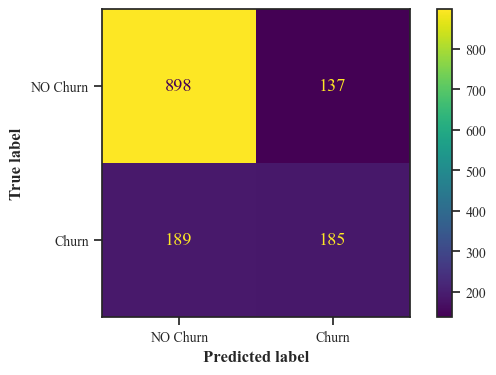

In [64]:
cm = confusion_matrix(y_test, y_pred_gb)
display = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels= ["NO Churn", "Churn"]
)
display.plot()

In [65]:
# =========================================
# Frozen Comparison Model
# Gradient Boosting Classifier
# =========================================

## Model Comparison

Multiple classification models are evaluated using consistent preprocessing and evaluation criteria.  
Models are compared based on recall for the churn class and ROC AUC to ensure a fair and goal-oriented selection process.

The following models were evaluated:

- Logistic Regression (class-weighted)
- Random Forest
- Gradient Boosting

The comparison was performed using:
- Recall (churn class)
- ROC AUC

In [66]:
models = {
    "Logistic Regression (Weighted)": lr_model_weighted,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Recall (Churn)": recall_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df
# results_df.sort_values(by="Recall (Churn)", ascending=False)

,Model,Recall (Churn),ROC AUC,Accuracy
0,Logistic Regression (Weighted),0.772727,0.837312,0.738822
1,Random Forest,0.652406,0.827313,0.767211
2,Gradient Boosting,0.494652,0.804858,0.768630


# Final Model Selection

Based on the evaluation results, a class-weighted logistic regression model is selected as the final model due to its strong recall performance, competitive ROC AUC, and interpretability.

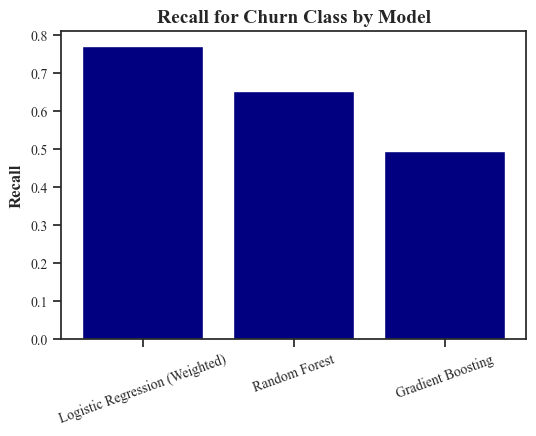

In [67]:
plt.figure(figsize= (6, 4))
plt.bar(
    results_df["Model"],
    results_df["Recall (Churn)"],
    color= "navy"
)
plt.title("Recall for Churn Class by Model")
plt.ylabel("Recall")
plt.xticks(rotation= 20)
plt.show()

In [68]:
lr_clf = lr_model_weighted.named_steps["classifier"]

feature_names = lr_model_weighted.named_steps["preprocessor"].get_feature_names_out()

In [69]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_clf.coef_[0]
})

In [70]:
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df_sorted = coef_df.sort_values(
    by="abs_coefficient",
    ascending= False
)

In [71]:
coef_df_sorted.head(10)      

,feature,coefficient,abs_coefficient
34,cat__Contract_Two year,-0.798784,0.798784
0,num__tenure,-0.747820,0.747820
12,cat__InternetService_Fiber optic,0.701127,0.701127
11,cat__InternetService_DSL,-0.661940,0.661940
32,cat__Contract_Month-to-month,0.643058,0.643058
1,num__MonthlyCharges,-0.540416,0.540416
5,bin__PaperlessBilling_Yes,0.333422,0.333422
15,cat__OnlineSecurity_No internet service,-0.295986,0.295986
30,cat__StreamingMovies_No internet service,-0.295986,0.295986
27,cat__StreamingTV_No internet service,-0.295986,0.295986


In [72]:
coef_df_sorted.tail(10)      

,feature,coefficient,abs_coefficient
7,cat__gender_Male,-0.108587,0.108587
33,cat__Contract_One year,-0.101073,0.101073
25,cat__TechSupport_Yes,-0.100240,0.100240
38,cat__PaymentMethod_Mailed check,-0.099119,0.099119
22,cat__DeviceProtection_Yes,0.061900,0.061900
4,bin__PhoneService_Yes,-0.054195,0.054195
17,cat__OnlineBackup_No,0.032621,0.032621
2,bin__Partner_Yes,0.026284,0.026284
20,cat__DeviceProtection_No,-0.022713,0.022713
19,cat__OnlineBackup_Yes,0.006566,0.006566


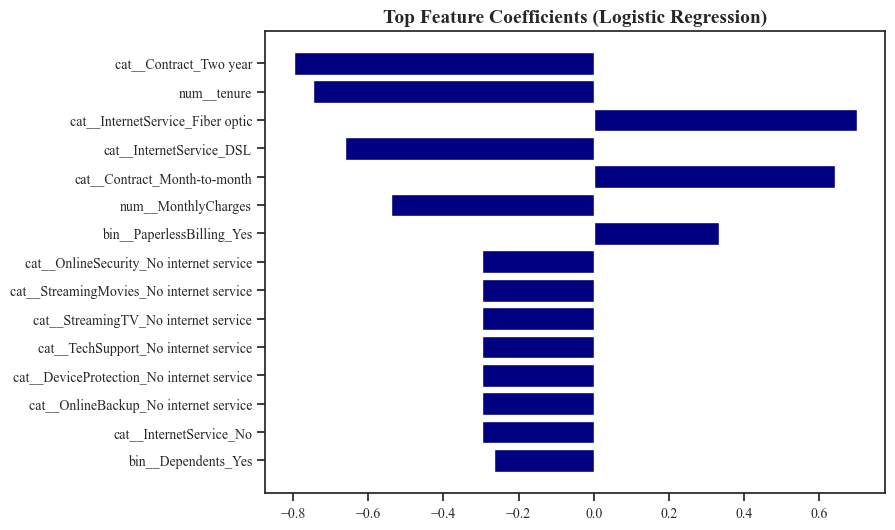

In [73]:
top_features = coef_df_sorted.head(15)

plt.figure(figsize= (8, 6))
plt.barh(top_features["feature"], top_features["coefficient"], color= "navy")
plt.gca().invert_yaxis()
plt.title("Top Feature Coefficients (Logistic Regression)")
plt.show()

## Conclusion

In this project, an end-to-end machine learning workflow was developed to predict customer churn.  
Multiple classification models were evaluated using consistent preprocessing and evaluation criteria.

A class-weighted logistic regression model was selected as the final model due to its strong recall performance on the churn class, competitive ROC AUC, and interpretability. This balance makes the model well-suited for business scenarios where identifying at-risk customers is a priority.

Feature importance analysis provided insights into the key factors influencing churn, enabling the results to be translated into actionable business understanding.

Future improvements may include additional feature engineering, hyperparameter tuning, and evaluation with cross-validation to further enhance model robustness.